# RINEX 4 QC
Basic sanity checks on a RINEX 3/4 observation file: satellites tracked per constellation over time, plus header/sampling/signal-quality checks.

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

CONSTELLATION_NAMES = {
    "G": "GPS", "R": "GLONASS", "E": "Galileo", "C": "BeiDou",
    "J": "QZSS", "I": "IRNSS", "S": "SBAS",
}

## Input

In [2]:
RINEX_PATH = Path("/Users/mikegottlieb/data/sfg/cascadia-gorda/NCC1/2025_A_1126/processed/rinex/NCC100USA_R_20252560001_01D_02S_MO.rnx")  # <-- set this

## Parse header + epochs
Lightweight fixed-width RINEX 3/4 OBS parser (no external rinex library needed). Each observation field is a 16-char slot: 14-char value + 1-char LLI + 1-char signal-strength flag, starting right after the 3-char satellite id.

In [3]:
def parse_rinex_header(path):
    header = {
        "obs_types": {}, "approx_position": None, "interval": None,
        "time_first_obs": None, "time_last_obs": None, "marker_name": None,
    }
    cur_sys, cur_remaining = None, 0
    with open(path) as f:
        for line in f:
            label = line[60:].strip()
            if label == "END OF HEADER":
                break
            if label.startswith("SYS / # / OBS TYPES"):
                tokens = line[:60].split()
                if cur_remaining <= 0:
                    cur_sys, cur_remaining = tokens[0], int(tokens[1])
                    codes = tokens[2:]
                else:
                    codes = tokens
                header["obs_types"].setdefault(cur_sys, []).extend(codes)
                cur_remaining -= len(codes)
            elif label.startswith("APPROX POSITION XYZ"):
                header["approx_position"] = tuple(float(v) for v in line[:60].split())
            elif label.startswith("INTERVAL"):
                header["interval"] = float(line[:60].split()[0])
            elif label.startswith("TIME OF FIRST OBS"):
                p = line[:60].split()
                header["time_first_obs"] = datetime(*(int(v) for v in p[:5]), int(float(p[5])))
            elif label.startswith("TIME OF LAST OBS"):
                p = line[:60].split()
                header["time_last_obs"] = datetime(*(int(v) for v in p[:5]), int(float(p[5])))
            elif label.startswith("MARKER NAME"):
                header["marker_name"] = line[:60].strip()
    return header

In [4]:
def parse_rinex_epochs(path):
    """One record per epoch: time, flag, header-reported nsat, and raw obs lines
    (only kept for flag 0/1 epochs - flag>1 epochs carry special event records,
    not satellite observations, in the lines that follow)."""
    epochs = []
    in_header = True
    cur = None
    with open(path) as f:
        for line in f:
            if in_header:
                if line[60:].strip() == "END OF HEADER":
                    in_header = False
                continue
            if line.startswith(">"):
                if cur is not None:
                    epochs.append(cur)
                parts = line[1:].split()
                y, mo, d, h, mi = (int(v) for v in parts[:5])
                sec = float(parts[5])
                flag, nsat = int(parts[6]), int(parts[7])
                time = datetime(y, mo, d, h, mi) + timedelta(seconds=sec)
                cur = {"time": time, "flag": flag, "nsat": nsat, "lines": []}
            elif cur is not None and cur["flag"] in (0, 1) and line.strip():
                cur["lines"].append(line.rstrip("\n"))
        if cur is not None:
            epochs.append(cur)
    return epochs

In [5]:
header = parse_rinex_header(RINEX_PATH)
epochs = parse_rinex_epochs(RINEX_PATH)

records = []
for ep in epochs:
    counts = defaultdict(int)
    for line in ep["lines"]:
        counts[line[0]] += 1
    row = {"time": ep["time"], "flag": ep["flag"], "nsat_header": ep["nsat"], "nsat_total": len(ep["lines"])}
    row.update(counts)
    records.append(row)

epoch_df = pd.DataFrame(records).set_index("time").sort_index()
constellation_cols = sorted(c for c in epoch_df.columns if c not in ("flag", "nsat_header", "nsat_total"))
epoch_df[constellation_cols] = epoch_df[constellation_cols].fillna(0).astype(int)

print(f"{len(epoch_df)} epochs parsed, {len(constellation_cols)} constellation(s): {constellation_cols}")
epoch_df.head()

774 epochs parsed, 2 constellation(s): ['G', 'R']


,flag,nsat_header,nsat_total,G,R
time,,,,,
2025-09-13 00:01:23.000,0,16,16,10,6
2025-09-13 00:01:24.600,0,16,16,10,6
2025-09-13 00:01:25.400,0,16,16,10,6
2025-09-13 00:01:26.200,0,16,16,10,6
2025-09-13 00:03:23.000,0,15,15,10,5


## Satellites per constellation vs time

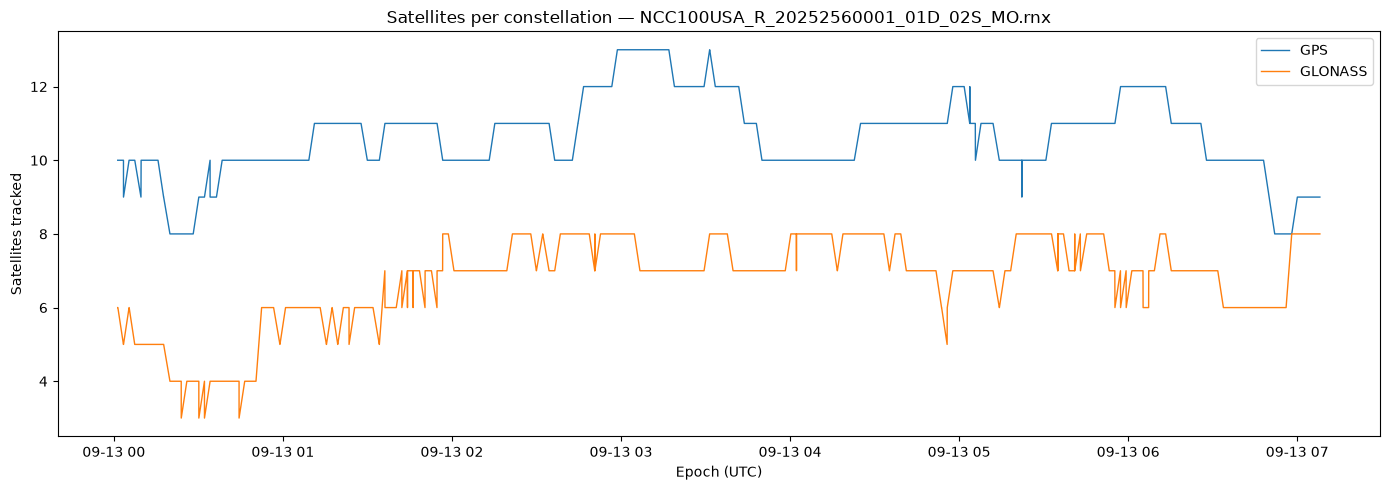

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
for col in constellation_cols:
    ax.plot(epoch_df.index, epoch_df[col], label=CONSTELLATION_NAMES.get(col, col), linewidth=1)
ax.set_xlabel("Epoch (UTC)")
ax.set_ylabel("Satellites tracked")
ax.set_title(f"Satellites per constellation \u2014 {RINEX_PATH.name}")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## Other basic QC checks

### Header sanity

In [7]:
print("Marker:", header["marker_name"])
print("Obs types:", header["obs_types"])
print("Interval (header):", header["interval"])
print("Time of first/last obs (header):", header["time_first_obs"], header["time_last_obs"])

if header["approx_position"] in (None, (0.0, 0.0, 0.0)):
    print("WARNING: APPROX POSITION XYZ is unset (all-zero) - downstream a-priori/elevation-mask steps may be affected.")

if header["time_first_obs"] and header["time_first_obs"] != epoch_df.index.min():
    print(f"NOTE: header TIME OF FIRST OBS ({header['time_first_obs']}) != first parsed epoch ({epoch_df.index.min()}).")
if header["time_last_obs"] and header["time_last_obs"] != epoch_df.index.max():
    print(f"NOTE: header TIME OF LAST OBS ({header['time_last_obs']}) != last parsed epoch ({epoch_df.index.max()}).")

Marker: NCC1
Obs types: {'G': ['L1C', 'C1C', 'S1C', 'L2W', 'C2W', 'S2W'], 'R': ['L1C', 'C1C', 'S1C', 'L2P', 'C2P', 'S2P']}
Interval (header): None
Time of first/last obs (header): 2025-09-13 00:01:23 2025-09-13 07:08:01
NOTE: header TIME OF LAST OBS (2025-09-13 07:08:01) != last parsed epoch (2025-09-13 07:08:01.800000).


### Epoch flags (power failures / special events)

In [8]:
flag_counts = epoch_df["flag"].value_counts().sort_index()
print("Epoch flag counts (0=OK, 1=power failure since last epoch, >1=special event record):")
flag_counts

Epoch flag counts (0=OK, 1=power failure since last epoch, >1=special event record):


flag
0    774
Name: count, dtype: int64

### Sampling gaps / duplicate or out-of-order epochs

In [9]:
diffs = epoch_df.index.to_series().diff().dt.total_seconds()
nominal = diffs.mode().iloc[0] if not diffs.dropna().empty else None
print(f"Nominal sample interval (mode of dt): {nominal} s")

gaps = diffs[diffs > 1.5 * nominal]
print(f"{len(gaps)} gap(s) larger than 1.5x nominal interval:")
display(gaps)

print("Duplicate epoch timestamps:", epoch_df.index.duplicated().sum())

raw_times = [ep["time"] for ep in epochs]
non_monotonic = sum(1 for a, b in zip(raw_times, raw_times[1:]) if b < a)
print("Out-of-order epochs in raw file order:", non_monotonic)

Nominal sample interval (mode of dt): 1.8 s
209 gap(s) larger than 1.5x nominal interval:


time
2025-09-13 00:03:23    116.800
2025-09-13 00:05:23    117.000
2025-09-13 00:07:23    117.000
2025-09-13 00:09:38    132.000
2025-09-13 00:11:38    116.800
                        ...   
2025-09-13 07:00:00    117.801
2025-09-13 07:02:00    118.000
2025-09-13 07:04:00    118.000
2025-09-13 07:06:00    118.000
2025-09-13 07:08:00    117.801
Name: time, Length: 209, dtype: float64

Duplicate epoch timestamps: 0
Out-of-order epochs in raw file order: 0


### Total satellites tracked vs time (fix-availability dropouts)

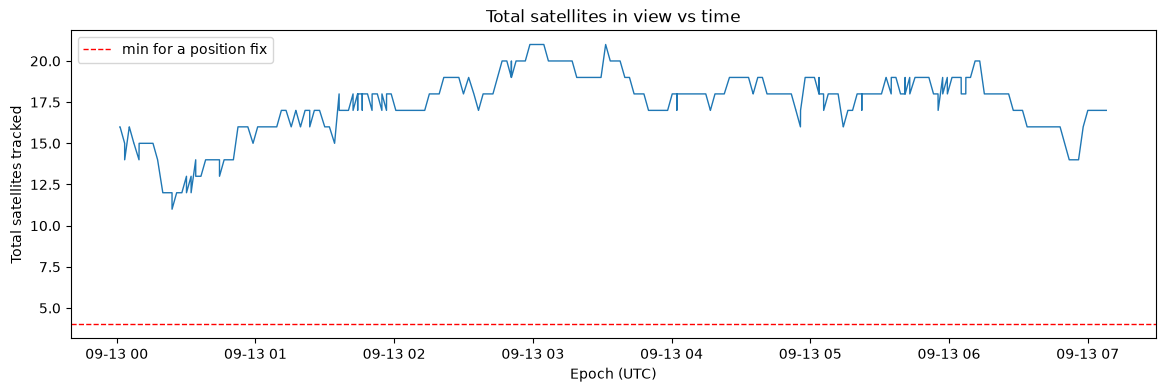

0 epoch(s) with fewer than 4 total satellites tracked


,flag,nsat_header,nsat_total,G,R
time,,,,,


In [10]:
MIN_SATS_FOR_FIX = 4

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(epoch_df.index, epoch_df["nsat_total"], linewidth=1)
ax.axhline(MIN_SATS_FOR_FIX, color="red", linestyle="--", linewidth=1, label="min for a position fix")
ax.set_xlabel("Epoch (UTC)")
ax.set_ylabel("Total satellites tracked")
ax.set_title("Total satellites in view vs time")
ax.legend()
plt.show()

low = epoch_df[epoch_df["nsat_total"] < MIN_SATS_FOR_FIX]
print(f"{len(low)} epoch(s) with fewer than {MIN_SATS_FOR_FIX} total satellites tracked")
low

### Signal strength (SNR) distribution per constellation
Uses each system's first `S*` observable (signal strength, dB-Hz). This re-scans every obs line so it's the slowest cell here - fine for a day of data, may be slow for multi-day files.

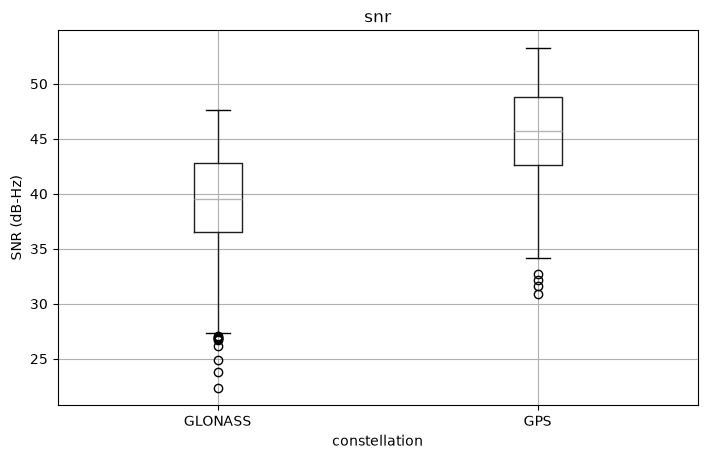

In [11]:
def extract_obs(line, sys_letter, obs_code, header):
    codes = header["obs_types"].get(sys_letter)
    if not codes or obs_code not in codes:
        return None
    start = 3 + codes.index(obs_code) * 16
    try:
        return float(line[start:start + 14])
    except ValueError:
        return None

snr_code = {
    sys_letter: next((c for c in codes if c.startswith("S")), None)
    for sys_letter, codes in header["obs_types"].items()
}

snr_rows = []
for ep in epochs:
    for line in ep["lines"]:
        sys_letter = line[0]
        code = snr_code.get(sys_letter)
        if code is None:
            continue
        val = extract_obs(line, sys_letter, code, header)
        if val is not None:
            snr_rows.append({"constellation": CONSTELLATION_NAMES.get(sys_letter, sys_letter), "snr": val})

snr_df = pd.DataFrame(snr_rows)
fig, ax = plt.subplots(figsize=(8, 5))
snr_df.boxplot(column="snr", by="constellation", ax=ax)
ax.set_ylabel("SNR (dB-Hz)")
plt.suptitle("")
plt.show()

### Observable completeness by type
For each declared observable (per constellation), what fraction of satellite-epoch records actually have a parseable value - vs. a blank field (satellite tracked, but that particular signal/channel wasn't). Reuses `extract_obs` from the SNR cell above, so run that cell first.

In [12]:
sys_line_count = defaultdict(int)          # total satellite-epoch lines seen per system (denominator)
obs_valid_count = defaultdict(lambda: defaultdict(int))  # valid-value count per (system, obs_code)
per_epoch_rows = []

for ep in epochs:
    epoch_sys_count = defaultdict(int)
    epoch_valid = defaultdict(lambda: defaultdict(int))
    for line in ep["lines"]:
        sys_letter = line[0]
        sys_line_count[sys_letter] += 1
        epoch_sys_count[sys_letter] += 1
        for code in header["obs_types"].get(sys_letter, []):
            if extract_obs(line, sys_letter, code, header) is not None:
                obs_valid_count[sys_letter][code] += 1
                epoch_valid[sys_letter][code] += 1
    row = {"time": ep["time"]}
    for sys_letter, codes in header["obs_types"].items():
        denom = epoch_sys_count.get(sys_letter, 0)
        for code in codes:
            row[f"{sys_letter}:{code}"] = 100 * epoch_valid[sys_letter][code] / denom if denom else float("nan")
    per_epoch_rows.append(row)

completeness_ts = pd.DataFrame(per_epoch_rows).set_index("time")

completeness_summary = pd.DataFrame([
    {
        "constellation": CONSTELLATION_NAMES.get(sys_letter, sys_letter),
        "obs_code": code,
        "completeness_pct": 100 * obs_valid_count[sys_letter][code] / sys_line_count[sys_letter] if sys_line_count[sys_letter] else float("nan"),
    }
    for sys_letter, codes in header["obs_types"].items() for code in codes
])
completeness_summary

,constellation,obs_code,completeness_pct
0,GPS,L1C,100.000000
1,GPS,C1C,100.000000
2,GPS,S1C,100.000000
3,GPS,L2W,99.975769
4,GPS,C2W,99.975769
5,GPS,S2W,99.975769
6,GLONASS,L1C,100.000000
7,GLONASS,C1C,100.000000
8,GLONASS,S1C,100.000000
9,GLONASS,L2P,74.799082


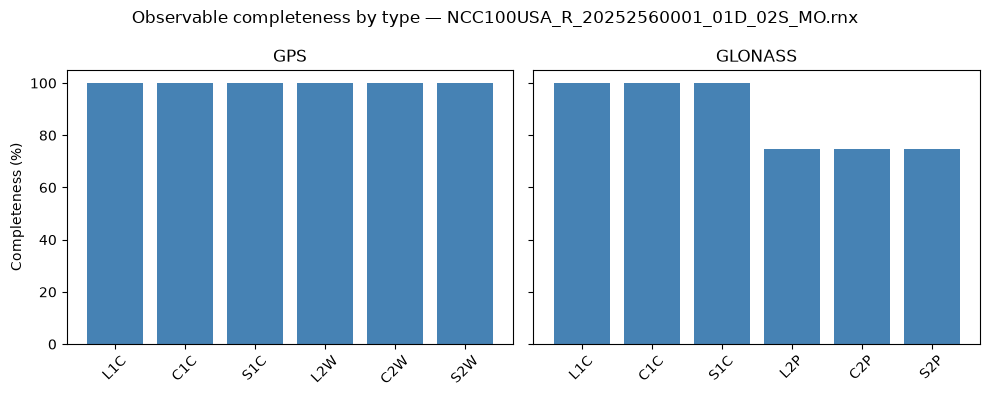

In [13]:
systems = list(header["obs_types"].items())
fig, axes = plt.subplots(1, len(systems), figsize=(5 * len(systems), 4), sharey=True)
if len(systems) == 1:
    axes = [axes]
for ax, (sys_letter, codes) in zip(axes, systems):
    pct = [100 * obs_valid_count[sys_letter][c] / sys_line_count[sys_letter] if sys_line_count[sys_letter] else 0 for c in codes]
    ax.bar(codes, pct, color="steelblue")
    ax.set_title(CONSTELLATION_NAMES.get(sys_letter, sys_letter))
    ax.set_ylim(0, 105)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Completeness (%)")
fig.suptitle(f"Observable completeness by type — {RINEX_PATH.name}")
fig.tight_layout()
plt.show()

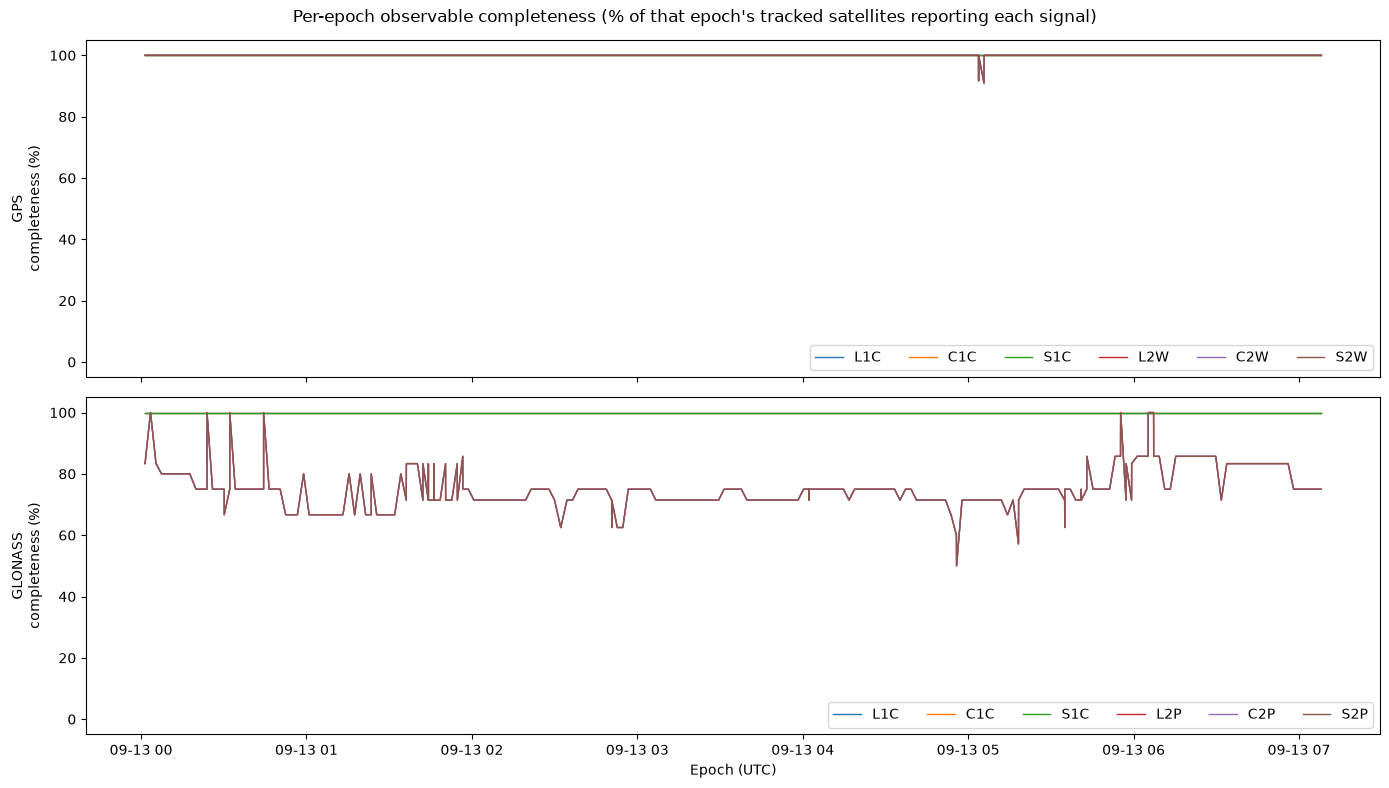

In [14]:
fig, axes = plt.subplots(len(systems), 1, figsize=(14, 4 * len(systems)), sharex=True)
if len(systems) == 1:
    axes = [axes]
for ax, (sys_letter, codes) in zip(axes, systems):
    for code in codes:
        ax.plot(completeness_ts.index, completeness_ts[f"{sys_letter}:{code}"], label=code, linewidth=1)
    ax.set_ylabel(f"{CONSTELLATION_NAMES.get(sys_letter, sys_letter)}\ncompleteness (%)")
    ax.set_ylim(-5, 105)
    ax.legend(loc="lower right", ncol=len(codes))
axes[-1].set_xlabel("Epoch (UTC)")
fig.suptitle("Per-epoch observable completeness (% of that epoch's tracked satellites reporting each signal)")
fig.tight_layout()
plt.show()

### Further checks worth adding (not implemented here)
- **Cycle-slip rate**: the LLI flag bit (the char right after each phase value, e.g. `L1C`) marks slips directly - tally per satellite instead of inferring from phase differencing.
- **Multipath / elevation-angle-dependent SNR**: needs a broadcast/precise ephemeris to compute elevation; low-elevation SNR sag is a classic antenna/multipath signature.
- **PRN consistency vs a NAV file**: flag PRNs tracked in the OBS file that aren't in the matching NAV/SP3 (or vice versa - expected-but-missing satellites).
- **Receiver clock offset jumps**: the optional last field on the epoch (`>`) line, if present - large jumps can indicate clock resets.
- **Pseudorange/phase consistency**: `C1C - L1C*wavelength` should be slowly varying; large or noisy differences flag bad tracking.
- **Compression round-trip**: if the source file was Hatanaka-compressed, confirm decompression didn't silently drop epochs (compare epoch count against the `.crx`/`.d` original).